[INFO] Min common length = 200


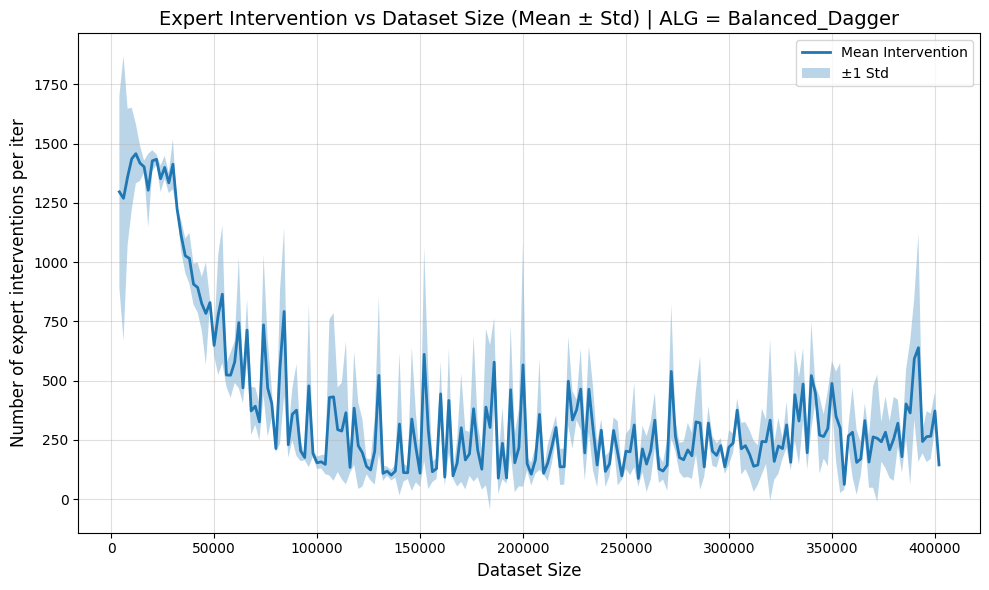

In [ ]:
# expert intervention plot 


import json
import os
import numpy as np
import matplotlib.pyplot as plt


def plot_nswitch_from_checkpoints(checkpoint_roots):

    all_nswitches = []
    all_dataset_sizes = []

    # --------------------------------
    # Load all results first
    # --------------------------------
    for root in checkpoint_roots:
        result_path = os.path.join(root, "results.json")

        if not os.path.exists(result_path):
            raise FileNotFoundError(f"results.json not found: {result_path}")

        with open(result_path, "r") as f:
            results = json.load(f)

        dataset_sizes = np.array(results["dataset_sizes"])
        nswitches = np.array(results["nswitches"])

        all_dataset_sizes.append(dataset_sizes)
        all_nswitches.append(nswitches)

    # --------------------------------
    # Find minimum length
    # --------------------------------
    min_len = min(len(x) for x in all_nswitches)
    print(f"[INFO] Min common length = {min_len}")

    # --------------------------------
    # Crop to minimum length
    # --------------------------------
    all_nswitches = [x[:min_len] for x in all_nswitches]
    all_dataset_sizes = [x[:min_len] for x in all_dataset_sizes]

    # reference x-axis (첫 번째 실험 기준)
    dataset_sizes_ref = all_dataset_sizes[0]

    # stack: (N, min_len)
    all_nswitches = np.stack(all_nswitches, axis=0)

    # --------------------------------
    # Mean / Std
    # --------------------------------
    mean_nswitch = np.mean(all_nswitches, axis=0)
    std_nswitch  = np.std(all_nswitches, axis=0)

    # --------------------------------
    # Plot
    # --------------------------------
    plt.figure(figsize=(10, 6))

    plt.plot(dataset_sizes_ref, mean_nswitch,
             linewidth=2,
             label="Mean Intervention")

    plt.fill_between(
        dataset_sizes_ref,
        mean_nswitch - std_nswitch,
        mean_nswitch + std_nswitch,
        alpha=0.3,
        label="±1 Std"
    )

    plt.xlabel("Dataset Size", fontsize=12)
    plt.ylabel("Number of expert interventions per iter", fontsize=12)
    plt.title("Expert Intervention vs Dataset Size (Mean ± Std) | ALG = Balanced_Dagger", fontsize=14)


    plt.grid(True, alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()


checkpoint_dirs = [
    "/AILAB-summer-school-2025/checkpoints/total/[Balanced_Dagger]rnd_iter200_balance_True_epoch_10_alpha_0.7_minDemo70_H0_FTrue_seed2",
    "/AILAB-summer-school-2025/checkpoints/total/[Balanced_Dagger]rnd_iter200_balance_True_epoch_10_alpha_0.7_minDemo70_H0_FTrue_seed13",
    "/AILAB-summer-school-2025/checkpoints/total/[Balanced_Dagger]rnd_iter200_balance_True_epoch_10_alpha_0.7_minDemo70_H0_FTrue_seed42",
]

plot_nswitch_from_checkpoints(checkpoint_dirs)


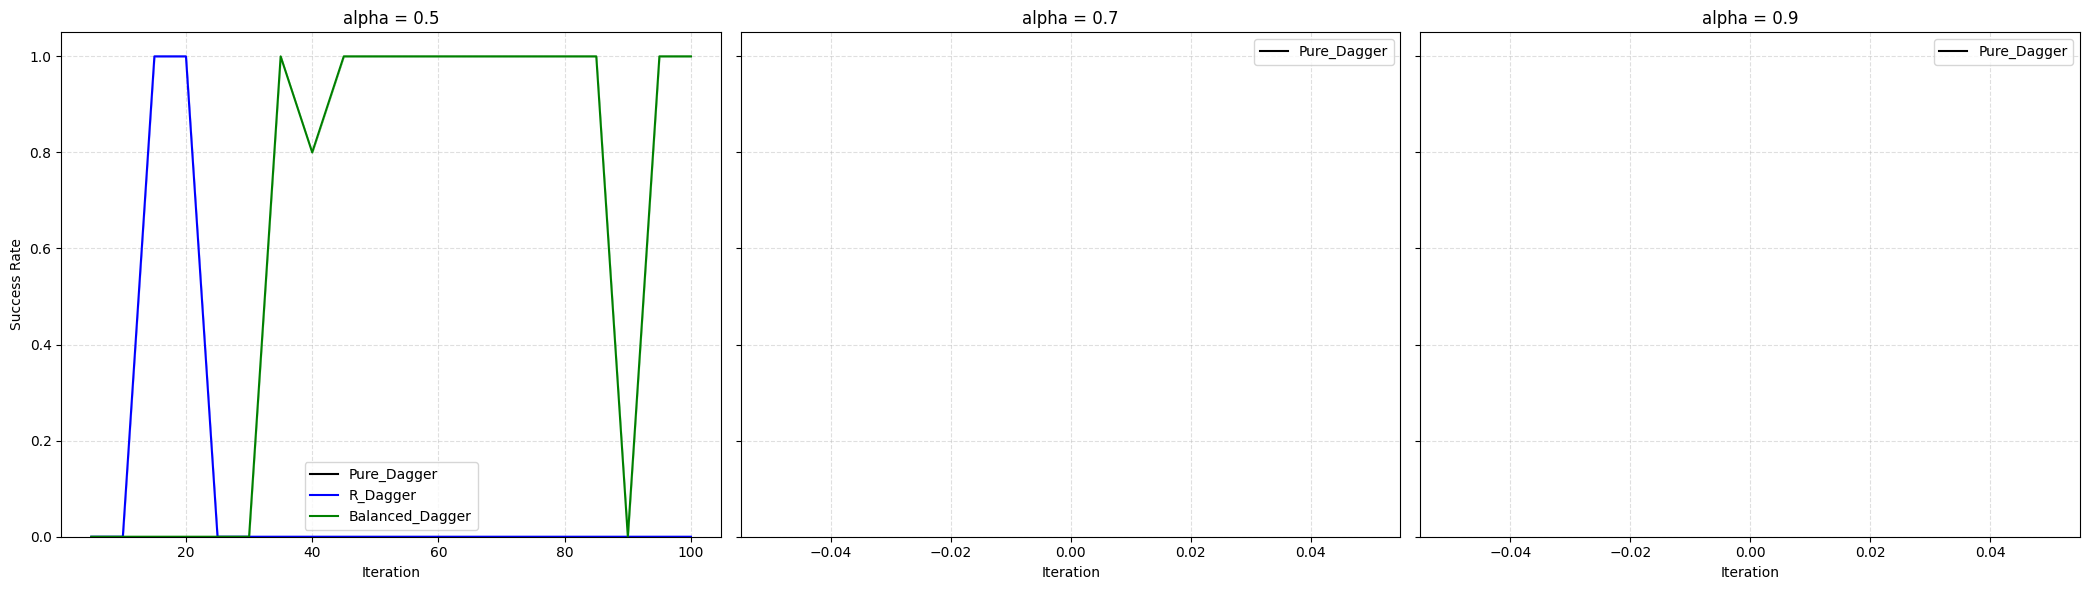

Saved: algo_alpha_success_rate.png


In [2]:
# success rate plot per alg & alpha

import json
import numpy as np
import matplotlib.pyplot as plt

# ===========================================
# 설정
# ===========================================
EVAL_JSON = "/AILAB-summer-school-2025/eval_all_iters.json"
TARGET_ALPHAS = [0.5, 0.7, 0.9]
ALGO_LIST = ["Pure_Dagger", "R_Dagger", "Balanced_Dagger", "Safe_Dagger"]
COLORS = {
    "Pure_Dagger": "black",
    "R_Dagger": "blue",
    "Balanced_Dagger": "green",
    "Safe_Dagger": "red"
}

# ===========================================
# 데이터 로드
# ===========================================
with open(EVAL_JSON, "r") as f:
    data = json.load(f)

pure_results = {}
if "Pure_Dagger" in data:
    seeds = data["Pure_Dagger"]["seeds"]
    all_iters = None
    for seed, seed_data in seeds.items():
        iters = sorted([int(k) for k in seed_data["iter_results"].keys()])
        if all_iters is None:
            all_iters = iters
        else:
            all_iters = sorted(list(set(all_iters) & set(iters)))

    # iter별 mean/std 계산
    pure_mean = []
    pure_std = []
    for it in all_iters:
        vals = []
        for seed, seed_data in seeds.items():
            vals.append(seed_data["iter_results"][str(it)])
        pure_mean.append(np.mean(vals))
        pure_std.append(np.std(vals))

    pure_results = {
        "iters": all_iters,
        "mean": pure_mean,
        "std": pure_std
    }

# ===========================================
# 3개의 subplot 생성
# ===========================================
fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharey=True)

for idx, alpha in enumerate(TARGET_ALPHAS):
    ax = axes[idx]
    ax.set_title(f"alpha = {alpha}")
    ax.set_xlabel("Iteration")
    if idx == 0:
        ax.set_ylabel("Success Rate")

    # ---------------------------------------
    # Pure_Dagger 먼저 그림 (alpha와 무관)
    # ---------------------------------------
    if pure_results:
        it = pure_results["iters"]
        mean = pure_results["mean"]
        std = pure_results["std"]
        ax.plot(it, mean, color=COLORS["Pure_Dagger"], label="Pure_Dagger")
        ax.fill_between(it, np.array(mean)-np.array(std), np.array(mean)+np.array(std),
                        color=COLORS["Pure_Dagger"], alpha=0.2)

    # ---------------------------------------
    # alpha가 있는 알고리즘들 그림
    # ---------------------------------------
    for algo in ALGO_LIST:
        if algo == "Pure_Dagger":
            continue  # 이미 그렸음

        if algo not in data:
            continue

        algo_block = data[algo]

        # alpha가 다르면 skip
        if str(alpha) != str(algo_block.get("alpha")):
            continue

        seeds = algo_block["seeds"]

        # iter intersection 찾기
        all_iters = None
        for seed, seed_data in seeds.items():
            iters = sorted([int(k) for k in seed_data["iter_results"].keys()])
            if all_iters is None:
                all_iters = iters
            else:
                all_iters = sorted(list(set(all_iters) & set(iters)))

        if all_iters is None:
            continue

        # mean/std 계산
        algo_mean = []
        algo_std = []
        for it in all_iters:
            vals = []
            for seed, seed_data in seeds.items():
                vals.append(seed_data["iter_results"][str(it)])
            algo_mean.append(np.mean(vals))
            algo_std.append(np.std(vals))

        # plot
        ax.plot(all_iters, algo_mean, color=COLORS[algo], label=algo)
        ax.fill_between(
            all_iters,
            np.array(algo_mean) - np.array(algo_std),
            np.array(algo_mean) + np.array(algo_std),
            color=COLORS[algo],
            alpha=0.2
        )

    ax.set_ylim(0, 1.05)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend()

plt.tight_layout()
plt.savefig("algo_alpha_success_rate.png", dpi=200)
plt.show()

print("Saved: algo_alpha_success_rate.png")

/tmp/ipykernel_159891/2409604495.py:128: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


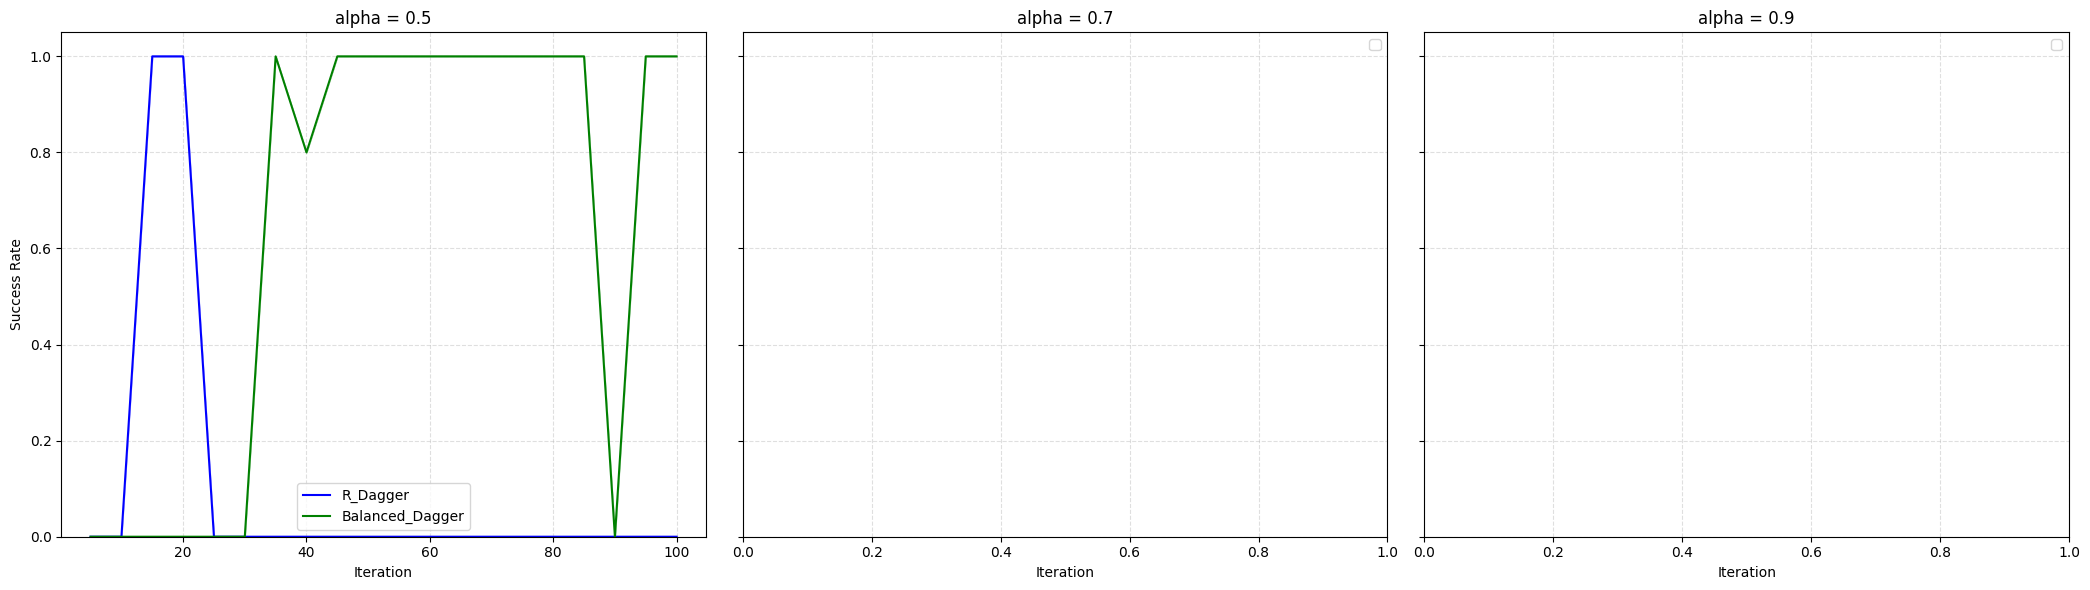

Saved: algo_alpha_success_rate.png


In [5]:
# success rate plot per alg & alpha

import json
import numpy as np
import matplotlib.pyplot as plt

# ===========================================
# 설정
# ===========================================
EVAL_JSON = "/AILAB-summer-school-2025/eval_all_iters.json"
TARGET_ALPHAS = [0.5, 0.7, 0.9]
ALGO_LIST = ["Pure_Dagger", "R_Dagger", "Balanced_Dagger", "Safe_Dagger"]
COLORS = {
    "Pure_Dagger": "black",
    "R_Dagger": "blue",
    "Balanced_Dagger": "green",
    "Safe_Dagger": "red"
}

# ===========================================
# 데이터 로드
# ===========================================
with open(EVAL_JSON, "r") as f:
    data = json.load(f)

pure_results = {}
if "Pure_Dagger" in data:
    seeds = data["Pure_Dagger"]["seeds"]
    all_iters = None
    for seed, seed_data in seeds.items():
        iters = sorted([int(k) for k in seed_data["iter_results"].keys()])
        if all_iters is None:
            all_iters = iters
        else:
            all_iters = sorted(list(set(all_iters) & set(iters)))

    # iter별 mean/std 계산
    pure_mean = []
    pure_std = []
    for it in all_iters:
        vals = []
        for seed, seed_data in seeds.items():
            vals.append(seed_data["iter_results"][str(it)])
        pure_mean.append(np.mean(vals))
        pure_std.append(np.std(vals))

    pure_results = {
        "iters": all_iters,
        "mean": pure_mean,
        "std": pure_std
    }

# ===========================================
# 3개의 subplot 생성
# ===========================================
fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharey=True)

for idx, alpha in enumerate(TARGET_ALPHAS):
    ax = axes[idx]
    ax.set_title(f"alpha = {alpha}")
    ax.set_xlabel("Iteration")
    if idx == 0:
        ax.set_ylabel("Success Rate")

    # ---------------------------------------
    # Pure_Dagger 먼저 그림 (alpha와 무관)
    # ---------------------------------------
    if pure_results:
        it = pure_results["iters"]
        mean = pure_results["mean"]
        std = pure_results["std"]
        ax.plot(it, mean, color=COLORS["Pure_Dagger"], label="Pure_Dagger")
        ax.fill_between(it, np.array(mean)-np.array(std), np.array(mean)+np.array(std),
                        color=COLORS["Pure_Dagger"], alpha=0.2)

    # ---------------------------------------
    # alpha가 있는 알고리즘들 그림
    # ---------------------------------------
    for algo in ALGO_LIST:
        if algo == "Pure_Dagger":
            continue  # 이미 그렸음

        if algo not in data:
            continue

        algo_block = data[algo]

        # alpha가 다르면 skip
        if str(alpha) != str(algo_block.get("alpha")):
            continue

        seeds = algo_block["seeds"]

        # iter intersection 찾기
        all_iters = None
        for seed, seed_data in seeds.items():
            iters = sorted([int(k) for k in seed_data["iter_results"].keys()])
            if all_iters is None:
                all_iters = iters
            else:
                all_iters = sorted(list(set(all_iters) & set(iters)))

        if all_iters is None:
            continue

        # mean/std 계산
        algo_mean = []
        algo_std = []
        for it in all_iters:
            vals = []
            for seed, seed_data in seeds.items():
                vals.append(seed_data["iter_results"][str(it)])
            algo_mean.append(np.mean(vals))
            algo_std.append(np.std(vals))

        # plot
        ax.plot(all_iters, algo_mean, color=COLORS[algo], label=algo)
        ax.fill_between(
            all_iters,
            np.array(algo_mean) - np.array(algo_std),
            np.array(algo_mean) + np.array(algo_std),
            color=COLORS[algo],
            alpha=0.2
        )

    ax.set_ylim(0, 1.05)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend()

plt.tight_layout()
plt.savefig("algo_alpha_success_rate.png", dpi=200)
plt.show()

print("Saved: algo_alpha_success_rate.png")

In [4]:
import os 
for f in os.listdir("/AILAB-summer-school-2025/checkpoints/total"):
    print("RAW:", repr(f))

    if "Decorate this" in f:  # placeholder
        pass

    if "[Pure_Dagger]" in f:
        print("FOUND PURE:", f)
    else:
        print("NOT PURE:", f)

    if "alpha_0.5" in f:
        print("HAS ALPHA:", f)
    else:
        print("NO ALPHA:", f)

RAW: '[Pure_Dagger]rnd_iter200_balance_False_epoch_10_alpha_0.5_minDemo70_H0_FTrue_seed13'
FOUND PURE: [Pure_Dagger]rnd_iter200_balance_False_epoch_10_alpha_0.5_minDemo70_H0_FTrue_seed13
HAS ALPHA: [Pure_Dagger]rnd_iter200_balance_False_epoch_10_alpha_0.5_minDemo70_H0_FTrue_seed13
RAW: '[Pure_Dagger]rnd_iter200_balance_False_epoch_10_alpha_0.5_minDemo70_H0_FTrue_seed2'
FOUND PURE: [Pure_Dagger]rnd_iter200_balance_False_epoch_10_alpha_0.5_minDemo70_H0_FTrue_seed2
HAS ALPHA: [Pure_Dagger]rnd_iter200_balance_False_epoch_10_alpha_0.5_minDemo70_H0_FTrue_seed2
RAW: '[Balanced_Dagger]rnd_iter200_balance_True_epoch_10_alpha_0.9_minDemo70_H0_FTrue_seed2'
NOT PURE: [Balanced_Dagger]rnd_iter200_balance_True_epoch_10_alpha_0.9_minDemo70_H0_FTrue_seed2
NO ALPHA: [Balanced_Dagger]rnd_iter200_balance_True_epoch_10_alpha_0.9_minDemo70_H0_FTrue_seed2
RAW: '[Balanced_Dagger]rnd_iter200_balance_True_epoch_10_alpha_0.5_minDemo70_H0_FTrue_seed42'
NOT PURE: [Balanced_Dagger]rnd_iter200_balance_True_epoch_10